[*********************100%***********************]  1 of 1 completed


Ticker        HSBA.L
Date                
2023-01-03       NaN
2023-01-04  0.025665
2023-01-05  0.040111
2023-01-06  0.005838
2023-01-09 -0.009497


<Axes: xlabel='Date'>

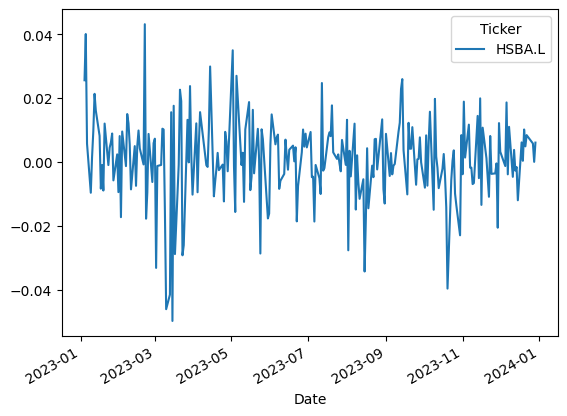

In [ ]:
import yfinance as yf
import pandas as pd
# Download historical data for HSBC Holdings plc (HSBA.L) from Yahoo Finance
data = yf.download("HSBA.L", start="2023-01-01", end="2024-01-01")
returns = data["Close"].squeeze().pct_change().dropna()
# Display the first few rows of the returns and plot them
print(returns.head())
returns.plot()

In [ ]:
# Value at Risk (VaR) calculations
import numpy as np
from scipy.stats import norm

# Historical VaR
def historical_var(returns, confidence = 0.99):
    return np.percentile(returns.dropna(), (1 - confidence) * 100)

# Parametric VaR
def parametric_var(returns, confidence = 0.99):
    mu = returns.mean()
    sigma = returns.std()
    return mu - sigma * norm.ppf(confidence)

In [3]:
portfolio_value = 10000 

h_var = historical_var(returns)
p_var = parametric_var(returns)

print(f"Portfolio value: £{portfolio_value:,.2f}")
print(f"Historical 99%: {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%: {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")

TypeError: float() argument must be a string or a real number, not 'Series'